In [42]:
import pandas as pd
import numpy as np
import seaborn as sb
df1=pd.read_csv("deliveries.csv")
df2=pd.read_csv("matches.csv")
df1

,match_id,over,ball,batsman,bowler,batsman_runs,extra_runs,total_runs,dismissal_kind,player_dismissed
0,1001,15,1,Virat Kohli,Jasprit Bumrah,1,0,1,NaN,NaN
1,1001,15,2,MS Dhoni,Jasprit Bumrah,0,0,0,NaN,NaN
2,1001,15,3,Ruturaj Gaikwad,Jasprit Bumrah,4,0,4,NaN,NaN
3,1001,15,4,Rinku Singh,Jasprit Bumrah,1,1,2,NaN,NaN
4,1001,15,5,Hardik Pandya,Jasprit Bumrah,6,0,6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
115,1004,19,2,Ruturaj Gaikwad,Yuzvendra Chahal,1,0,1,NaN,NaN
116,1004,19,3,Heinrich Klaasen,Yuzvendra Chahal,4,0,4,NaN,NaN
117,1004,19,4,MS Dhoni,Yuzvendra Chahal,2,0,2,NaN,NaN
118,1004,19,5,Ruturaj Gaikwad,Yuzvendra Chahal,6,0,6,NaN,NaN


In [25]:
df2

,match_id,season,venue,team1,team2,toss_winner,toss_decision,winner
0,1001,2024,M. Chinnaswamy Stadium,RCB,GT,RCB,field,GT
1,1002,2025,Narendra Modi Stadium,GT,MI,MI,field,MI
2,1003,2024,MA Chidambaram Stadium,CSK,KKR,CSK,bat,CSK
3,1004,2026,Wankhede Stadium,MI,RCB,MI,field,RCB
4,1005,2025,Eden Gardens,KKR,CSK,CSK,field,KKR
5,1006,2024,M. Chinnaswamy Stadium,RCB,MI,MI,field,MI
6,1007,2024,Narendra Modi Stadium,GT,CSK,GT,bat,CSK
7,1008,2026,MA Chidambaram Stadium,CSK,GT,GT,field,GT
8,1009,2025,Wankhede Stadium,MI,KKR,MI,bat,MI
9,1010,2025,Eden Gardens,KKR,RCB,KKR,field,RCB


In [5]:
print(pd.isnull(df1).sum())
print(pd.isnull(df2).sum())
df1.fillna("not out", inplace=True)
df2.fillna("no result", inplace=True)
print(df1)
print(df2)

match_id              0
over                  0
ball                  0
batsman               0
bowler                1
batsman_runs          0
extra_runs            0
total_runs            0
dismissal_kind      108
player_dismissed    108
dtype: int64
match_id         0
season           0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           1
dtype: int64
     match_id  over  ball           batsman            bowler  batsman_runs  \
0        1001    15     1       Virat Kohli    Jasprit Bumrah             1   
1        1001    15     2          MS Dhoni    Jasprit Bumrah             0   
2        1001    15     3   Ruturaj Gaikwad    Jasprit Bumrah             4   
3        1001    15     4       Rinku Singh    Jasprit Bumrah             1   
4        1001    15     5     Hardik Pandya    Jasprit Bumrah             6   
..        ...   ...   ...               ...               ...           ...   
115      1004    19     2   R

In [6]:
matches=df1.groupby("batsman")["match_id"].nunique()
print(matches)
players=matches[matches>20].index
print(players)
bat_df=df1[df1["batsman"].isin(players)]
print(bat_df)
career=bat_df.groupby("batsman").agg(
    runs=("batsman_runs","sum"),
    balls=("ball","count")
).reset_index()
print(career)
career["strike_rate"]=np.where(career["balls"]>0,(career["runs"]/career["balls"])*100,np.nan)
print(career)

batsman
Hardik Pandya       4
Heinrich Klaasen    4
MS Dhoni            4
Rinku Singh         4
Ruturaj Gaikwad     4
Virat Kohli         4
Name: match_id, dtype: int64
Index([], dtype='str', name='batsman')
Empty DataFrame
Columns: [match_id, over, ball, batsman, bowler, batsman_runs, extra_runs, total_runs, dismissal_kind, player_dismissed]
Index: []
Empty DataFrame
Columns: [batsman, runs, balls]
Index: []
Empty DataFrame
Columns: [batsman, runs, balls, strike_rate]
Index: []


In [7]:
matches=df1.groupby("bowler")["match_id"].nunique()
print(matches)
bowlers=matches[matches>20].index
print(bowlers)
bowl_df=df1[df1["bowler"].isin(bowlers)]
print(bowl_df)
bowl_stats=bowl_df.groupby("bowler").agg(
    runs_conceded=("total_runs","sum"),
    balls=("ball","count")
).reset_index()
print(bowl_stats)
bowl_stats["overs"]=bowl_stats["balls"]/6
print(bowl_stats)
bowl_stats["economy_rate"]=np.where(bowl_stats["overs"]>0,
                                    bowl_stats["runs_conceded"]/bowl_stats["overs"],np.nan)

bowler
Jasprit Bumrah      4
Mitchell Starc      4
Rashid Khan         4
Ravindra Jadeja     4
Yuzvendra Chahal    4
not out             1
Name: match_id, dtype: int64
Index([], dtype='str', name='bowler')
Empty DataFrame
Columns: [match_id, over, ball, batsman, bowler, batsman_runs, extra_runs, total_runs, dismissal_kind, player_dismissed]
Index: []
Empty DataFrame
Columns: [bowler, runs_conceded, balls]
Index: []
Empty DataFrame
Columns: [bowler, runs_conceded, balls, overs]
Index: []


     match_id  over  ball           batsman            bowler  batsman_runs  \
6        1001    16     1       Virat Kohli       Rashid Khan             1   
7        1001    16     2          MS Dhoni       Rashid Khan             4   
8        1001    16     3   Ruturaj Gaikwad       Rashid Khan             0   
9        1001    16     4       Rinku Singh       Rashid Khan             1   
10       1001    16     5     Hardik Pandya       Rashid Khan             2   
..        ...   ...   ...               ...               ...           ...   
115      1004    19     2   Ruturaj Gaikwad  Yuzvendra Chahal             1   
116      1004    19     3  Heinrich Klaasen  Yuzvendra Chahal             4   
117      1004    19     4          MS Dhoni  Yuzvendra Chahal             2   
118      1004    19     5   Ruturaj Gaikwad  Yuzvendra Chahal             6   
119      1004    19     6  Heinrich Klaasen  Yuzvendra Chahal             1   

     extra_runs  total_runs dismissal_kind player_d

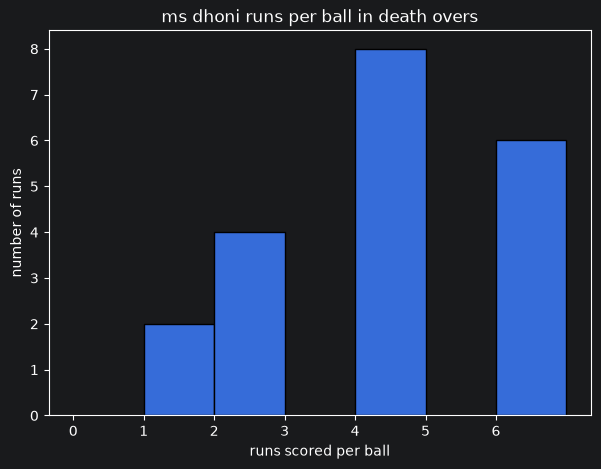

skewness:  -0.22748471772944442


In [8]:
import matplotlib.pyplot as plt
death_overs=df1[(df1["over"]>=16)&(df1["over"]<=20)]
print(death_overs)
dhoni=death_overs[death_overs["batsman"]=="MS Dhoni"]
print(dhoni)
plt.figure(figsize=(7,5))
plt.hist(dhoni["batsman_runs"],bins=[0,1,2,3,4,5,6,7],edgecolor="black")
plt.title("ms dhoni runs per ball in death overs")
plt.xlabel("runs scored per ball")
plt.ylabel("number of runs")
plt.xticks(range(7))
plt.show()
print("skewness: ",dhoni["batsman_runs"].skew())

             bowler  runs_conceded  balls
0    Jasprit Bumrah             38     24
1    Mitchell Starc             71     24
2       Rashid Khan             54     24
3   Ravindra Jadeja             57     23
4  Yuzvendra Chahal             72     24
             bowler  runs_conceded  balls     overs
0    Jasprit Bumrah             38     24  4.000000
1    Mitchell Starc             71     24  4.000000
2       Rashid Khan             54     24  4.000000
3   Ravindra Jadeja             57     23  3.833333
4  Yuzvendra Chahal             72     24  4.000000
economy:               bowler  runs_conceded  balls     overs  economy_rate bowling_type
0    Jasprit Bumrah             38     24  4.000000      9.500000         fast
1    Mitchell Starc             71     24  4.000000     17.750000         fast
2       Rashid Khan             54     24  4.000000     13.500000         spin
3   Ravindra Jadeja             57     23  3.833333     14.869565         spin
4  Yuzvendra Chahal            

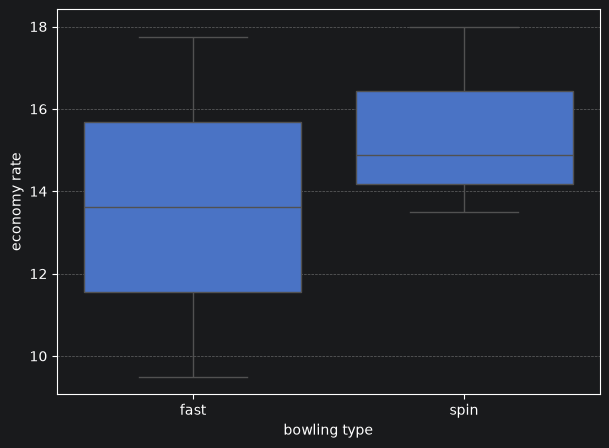

In [12]:
economy=df1.groupby("bowler").agg(
    runs_conceded=("total_runs","sum"),
    balls=("ball","count")
).reset_index()
print(economy)
economy["overs"]=economy["balls"]/6
print(economy)
economy["economy_rate"]=np.where(economy["overs"]>0,
                                    economy["runs_conceded"]/economy["overs"],np.nan)
spin_bowlers=["Rashid Khan","Ravindra Jadeja","Yuzvendra Chahal"]
economy["bowling_type"]=np.where(
    economy["bowler"].isin(spin_bowlers),"spin","fast"
)
required_bowlers=["Jasprit Bumrah","Mitchell Starc","Rashid Khan","Ravindra Jadeja","Yuzvendra Chahal"]
economy=economy[economy["bowler"].isin(required_bowlers)]
print("economy: ",economy)
plt.figure(figsize=(7,5))
sb.boxplot(x='bowling_type',y='economy_rate',data=economy)
plt.xlabel("bowling type")
plt.ylabel("economy rate")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

           batsman  runs  balls  outs  batting_avg  strike_rate
0    Hardik Pandya    31     17     4         7.75   182.352941
1         MS Dhoni    82     24     0        82.00   341.666667
2      Rinku Singh    48     22     1        48.00   218.181818
3  Ruturaj Gaikwad    38     18     2        19.00   211.111111
4      Virat Kohli    32     19     2        16.00   168.421053


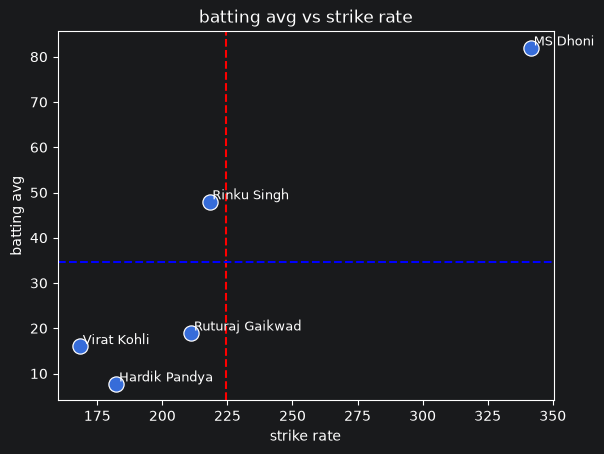

In [23]:
top_order=["Virat Kohli","Ruturaj Gaikwad","Hardik Pandya","Heinrich Klassen","MS Dhoni","Rinku Singh"]
bat_df=df1[df1["batsman"].isin(top_order)]
bat_stat=bat_df.groupby("batsman").agg(
    runs=("batsman_runs","sum"),
    balls=("ball","count"),
    outs=("dismissal_kind",lambda x:x.notna().sum())
).reset_index()
bat_stat["batting_avg"]=np.where(bat_stat["outs"]>0,bat_stat["runs"]/bat_stat["outs"],bat_stat["runs"])
bat_stat["strike_rate"]=(bat_stat["runs"]/bat_stat["balls"])*100
print(bat_stat)
sb.scatterplot(data=bat_stat,x="strike_rate",y="batting_avg",s=120)
for i in range(len(bat_stat)):
    plt.text(bat_stat["strike_rate"][i]+1,bat_stat["batting_avg"][i]+0.5,bat_stat["batsman"][i],fontsize=9)
plt.axvline(bat_stat["strike_rate"].mean(),color="red",linestyle="--")
plt.axhline(bat_stat["batting_avg"].mean(),color="blue",linestyle="--")
plt.title("batting avg vs strike rate")
plt.xlabel("strike rate")
plt.ylabel("batting avg")
plt.show()

    match_id  season                   venue team1 team2 toss_winner  \
0       1001    2024  M. Chinnaswamy Stadium   RCB    GT         RCB   
1       1002    2025   Narendra Modi Stadium    GT    MI          MI   
2       1003    2024  MA Chidambaram Stadium   CSK   KKR         CSK   
3       1004    2026        Wankhede Stadium    MI   RCB          MI   
4       1005    2025            Eden Gardens   KKR   CSK         CSK   
5       1006    2024  M. Chinnaswamy Stadium   RCB    MI          MI   
6       1007    2024   Narendra Modi Stadium    GT   CSK          GT   
7       1008    2026  MA Chidambaram Stadium   CSK    GT          GT   
8       1009    2025        Wankhede Stadium    MI   KKR          MI   
9       1010    2025            Eden Gardens   KKR   RCB         KKR   
10      1011    2024  M. Chinnaswamy Stadium   RCB   CSK         RCB   
11      1012    2026   Narendra Modi Stadium    GT   KKR         KKR   
12      1013    2024  MA Chidambaram Stadium   CSK    MI        

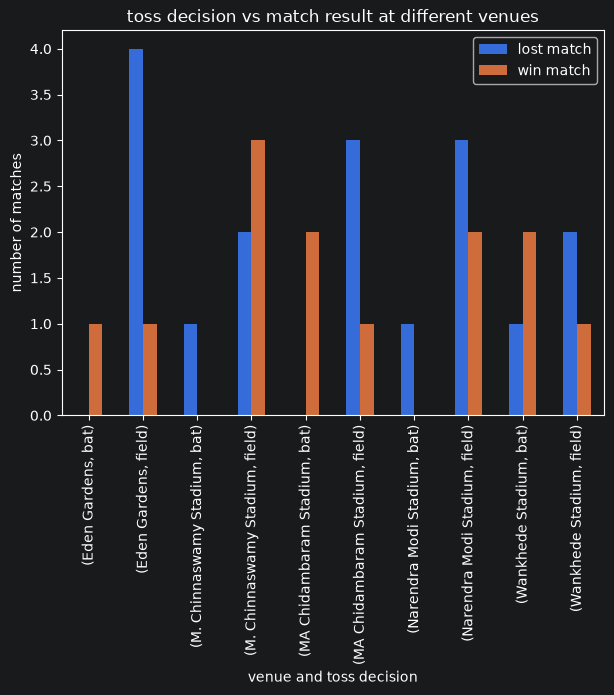

In [37]:
df2["toss_win"]=df2["toss_winner"]==df2["winner"]
print(df2)
result=df2.groupby(["venue","toss_decision","toss_win"]).size().unstack(fill_value=0)
print(result)
result.plot(kind="bar",figsize=(7,5))
plt.title("toss decision vs match result at different venues")
plt.xlabel("venue and toss decision")
plt.ylabel("number of matches")
plt.xticks(rotation=90)
plt.legend(["lost match","win match"])
plt.show()

                  match_id  powerplay_runs  middle_wickets  death_boundaries  \
match_id          1.000000             NaN       -0.258199         -0.134840   
powerplay_runs         NaN             NaN             NaN               NaN   
middle_wickets   -0.258199             NaN        1.000000         -0.870388   
death_boundaries -0.134840             NaN       -0.870388          1.000000   
match_result      0.258199             NaN       -0.333333          0.522233   

                  match_result  
match_id              0.258199  
powerplay_runs             NaN  
middle_wickets       -0.333333  
death_boundaries      0.522233  
match_result          1.000000  


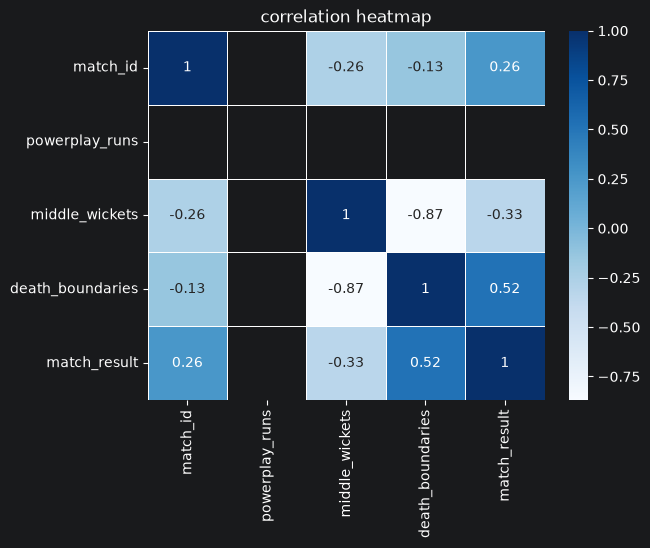

In [49]:
powerplay=df1[df1["over"]<=6].groupby("match_id")["total_runs"].sum()
middle=df1[(df1["over"]>=7)&(df1["over"]<=15)]
middle_wickets=middle.groupby("match_id")["dismissal_kind"].apply(lambda x:x.notna().sum())
death=df1[(df1["over"]>=16)&(df1["over"]<=20)]
death_boundaries=death[death["batsman_runs"].isin([4,6])].groupby("match_id").size()
analysis=pd.DataFrame({"powerplay_runs":powerplay,"middle_wickets":middle_wickets,"death_boundaries":death_boundaries}).fillna(0)
df2["match_result"]=(df2["winner"]==df2["team1"]).astype(int)
analysis=analysis.merge(df2[["match_id","match_result"]],on="match_id")
corr=analysis.corr()
print(corr)
sb.heatmap(corr, annot=True,cmap="Blues",linewidths=0.5)
plt.title("correlation heatmap")
plt.show()

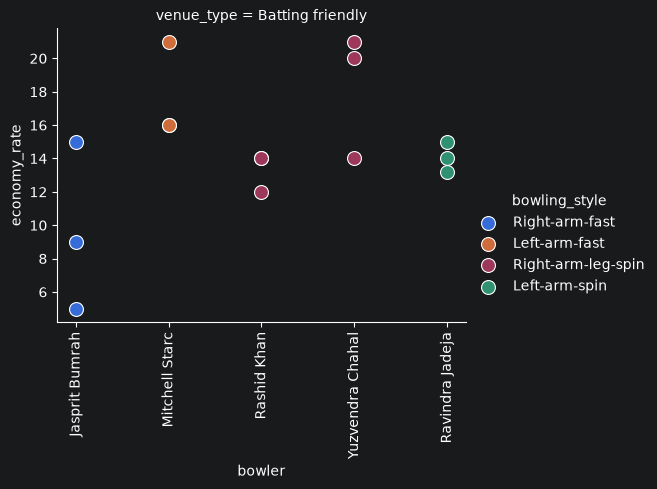

In [51]:
merged=pd.merge(df1,df2,on="match_id")
economy=merged.groupby(["bowler","venue"]).agg(runs_conceded=("total_runs","sum"),balls=("ball","count")).reset_index()
economy["overs"]=economy["balls"]/6
economy["economy_rate"]=economy["runs_conceded"]/economy["overs"]
economy["venue_type"]=economy["venue"].map(
    {
        "MA Chindabaram Stadium":"slowing",
        "Eden Gardens":"Batting friendly",
        "Wankhede Stadium":"Batting friendly",
        "M. Chinnaswamy Stadium":"Batting friendly",
        "Narendra Modi Stadium":"Batting friendly"
    }
)
economy["bowling_style"]=economy["bowler"].map({
    "Jasprit Bumrah":"Right-arm-fast",
    "Mitchell Starc":"Left-arm-fast",
    "Rashid Khan":"Right-arm-leg-spin",
    "Ravindra Jadeja":"Left-arm-spin",
    "Yuzvendra Chahal":"Right-arm-leg-spin",
})
economy=economy.dropna(subset=["venue_type","bowling_style"])
g=sb.FacetGrid(economy,col="venue_type",hue="bowling_style",height=5).tick_params(axis='x',rotation=90)
g.map_dataframe(sb.scatterplot,x="bowler",y="economy_rate",s=100)
g.add_legend()
plt.show()